# Milestone 6 Objective

Build the Test Planner Agent as a standalone agent before integrating it into the main LangGraph workflow.

## Test Planner Agent Role

The Test Planner reads compact repository evidence and produces a structured `test_plan`. It does not run tests and does not generate executable pytest, Selenium, Locust, or MCP code.

## Why It Works Alone First

The planner is validated as a standalone agent so its schema, grounding rules, and fallback behavior are correct before adding it to the larger workflow.

## Prompt Engineering Structure

The planner prompt follows: System Message + Few-Shot Example + User Input. The deterministic fallback uses the same evidence contract without calling an LLM.

## Grounding Rule

Every planned test must use `project_info`, `discovered_endpoints`, `discovered_ui_flows`, or `retrieved_context`. The planner must not invent endpoints, selectors, credentials, files, or business rules.

## Mini LangGraph Workflow

```text
START -> test_planner -> END
```

## Security Note

API keys are optional and never shown. Deterministic fallback works without keys, and this notebook does not run the target Django server or execute repository code.

## Target Repository

https://github.com/Vitaee/DjangoRestAPI

## Part A - Deterministic Fake Context

In [1]:
from pprint import pprint

from test_auto.agents.test_planner import run_test_planner_alone

project_info = {
    "language": "Python",
    "framework": "Django REST Framework",
    "has_api": True,
    "has_ui": True,
    "auth_type": "JWT",
}
discovered_endpoints = [
    {"method": "UNKNOWN", "path": "/api/todos/", "source_file": "todo/urls.py"},
    {"method": "UNKNOWN", "path": "/api/todos/<int:pk>/", "source_file": "todo/urls.py"},
]
discovered_ui_flows = [
    {"name": "login", "source_file": "templates/login.html", "flow_type": "authentication"}
]
retrieved_context = [
    {
        "source_path": "README.md",
        "content": "JWT authentication is required for the Todo API. Users can create, update, and delete tasks.",
        "score": 0.9,
        "reason": "Authentication and todo CRUD evidence",
        "chunk_type": "doc",
    }
]

planner_result = run_test_planner_alone(
    project_info=project_info,
    discovered_endpoints=discovered_endpoints,
    discovered_ui_flows=discovered_ui_flows,
    retrieved_context=retrieved_context,
    user_preferences={"test_types": ["api", "ui"]},
    use_llm=False,
)
pprint(planner_result["test_plan"])
pprint(planner_result["planner_model_info"])
pprint(planner_result["validation"])
print(planner_result["test_plan_path"])
print(planner_result["test_planner_result_path"])

{'api_tests': [{'assertions': [{'expected': 'Endpoint responds according to '
                                            'implementation.',
                                'target': None,
                                'type': 'custom'}],
                'auth_required': True,
                'category': 'smoke',
                'endpoint': '/api/todos/',
                'evidence_sources': ['todo/urls.py', 'README.md'],
                'expected_status': None,
                'id': 'API_001',
                'method': 'UNKNOWN',
                'name': 'smoke_api_todos',
                'objective': 'Verify the discovered endpoint /api/todos/ is '
                             'reachable according to repository evidence.',
                'priority': 'high',
                'request_body': None,
                'risks': ['Expected status may need refinement when executable '
                          'tests are added.']},
               {'assertions': [{'expected': '401',
           

## Part B - Run From A Previous Run Directory

This requires a previous Milestone 5 run that contains `workflow_state.json` or the separate `project_info.json`, `repo_analyzer_result.json`, and `retrieved_context.json` artifacts.

In [2]:
from pathlib import Path

from test_auto.agents.test_planner import load_planner_context_from_run_dir, run_test_planner_alone

candidate_runs = sorted(Path("results/runs").glob("*/workflow_state.json")) if Path("results/runs").exists() else []
if candidate_runs:
    run_dir = candidate_runs[-1].parent
    context = load_planner_context_from_run_dir(run_dir)
    run_dir_result = run_test_planner_alone(**context, run_id=run_dir.name, use_llm=False)
    pprint(run_dir_result["test_plan"])
else:
    print("No previous Milestone 5 run directory found yet.")

{'api_tests': [{'assertions': [{'expected': 'Endpoint responds according to '
                                            'implementation.',
                                'target': None,
                                'type': 'custom'}],
                'auth_required': True,
                'category': 'smoke',
                'endpoint': '/api/todos/',
                'evidence_sources': ['todo/urls.py', 'README.md'],
                'expected_status': None,
                'id': 'API_001',
                'method': 'UNKNOWN',
                'name': 'smoke_api_todos',
                'objective': 'Verify the discovered endpoint /api/todos/ is '
                             'reachable according to repository evidence.',
                'priority': 'high',
                'request_body': None,
                'risks': ['Expected status may need refinement when executable '
                          'tests are added.']},
               {'assertions': [{'expected': '401',
           

## Part C - Optional LLM Mode Safety

This requires a valid `.env` with Groq or Mistral configuration. The cell below displays only booleans and model names, never API keys.

In [3]:
from test_auto.planning.llm_planner import get_planner_llm_config, is_llm_planning_available
from test_auto.shared.secrets import get_llm_config

safe_llm_config = get_llm_config()
planner_llm_config = get_planner_llm_config()
pprint(safe_llm_config)
pprint(planner_llm_config)

if is_llm_planning_available():
    optional_llm_result = run_test_planner_alone(
        project_info=project_info,
        discovered_endpoints=discovered_endpoints,
        discovered_ui_flows=discovered_ui_flows,
        retrieved_context=retrieved_context,
        user_preferences={"test_types": ["api", "ui"]},
        use_llm=True,
    )
    pprint(optional_llm_result["planner_model_info"])
else:
    print("LLM planning unavailable; deterministic fallback remains available.")

{'groq_model': None,
 'has_groq_key': False,
 'has_mistral_key': False,
 'mistral_model': None,
 'provider': 'groq'}
{'available': False, 'model': None, 'provider': 'groq'}
LLM planning unavailable; deterministic fallback remains available.


## Part D - Mini LangGraph Workflow

In [4]:
from test_auto.graph.test_planner_workflow import run_test_planner_workflow

planner_state = {
    "project_info": project_info,
    "discovered_endpoints": discovered_endpoints,
    "discovered_ui_flows": discovered_ui_flows,
    "retrieved_context": retrieved_context,
    "user_preferences": {"test_types": ["api", "ui"], "use_llm": False},
    "missing_information": [],
    "errors": [],
    "agent_logs": [],
}
final_state = run_test_planner_workflow(planner_state)
pprint({
    "run_id": final_state.get("run_id"),
    "test_plan_path": final_state.get("test_plan_path"),
    "planner_model_info": final_state.get("planner_model_info"),
    "api_tests": len(final_state.get("test_plan", {}).get("api_tests", [])),
    "ui_tests": len(final_state.get("test_plan", {}).get("ui_tests", [])),
})

{'api_tests': 4,
 'planner_model_info': {'mode': 'deterministic_fallback',
                        'model': None,
                        'provider': 'none',
                        'reason': 'LLM disabled for this run.'},
 'run_id': 'run_20260520T084051Z_afe47519',
 'test_plan_path': 'results\\runs\\run_20260520T084051Z_afe47519\\test_plan.json',
 'ui_tests': 1}


## Part E - Graph Visualization

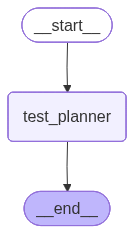

In [5]:
from IPython.display import Image, display
from test_auto.graph.test_planner_workflow import build_test_planner_graph

graph = build_test_planner_graph()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Graph image rendering failed; Mermaid text follows.")
    print(graph.get_graph().draw_mermaid())